This notebook is used to generate stock paths according to the CEV (Constant Elasticity of Variance) model. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, poisson
import yfinance as yf
from scipy.optimize import least_squares


The CEV differs from the GBM model covered in lecture in that it assumes that the volatality is a function of stock price.
In the Black Scholes GBM model, we solve the ODE:

$$
dS_t = \mu S_t \, dt + S_t \sigma \sqrt {dt} \mathcal N(0,1)
$$

where $\sigma$ is a constant. However in the CEV model, we assume that the volatality $\sigma(S_t)$ is a function of stock price, given by $\sigma(S) = a S^{\beta}$. Therefore the ODE now becomes:
$$
dS_t = \mu S_t \, dt + aS_t^{\beta+1}  \sqrt {dt} \mathcal N(0,1)
$$
The value of $\beta$ is now a parameter that has to be choosen. When $\beta=0$, this gives us the GBM scenario of constant volatality. When $\beta>0$, we assume, as the stock gets pricier, volatality increases. This is a good model for the recent surge in gold/bitcoin prices which saw heightened volatality upon the sudden surge in price a year ago. When $\beta < 0$, we assume the stock's volatality decreases after an increase in price. 

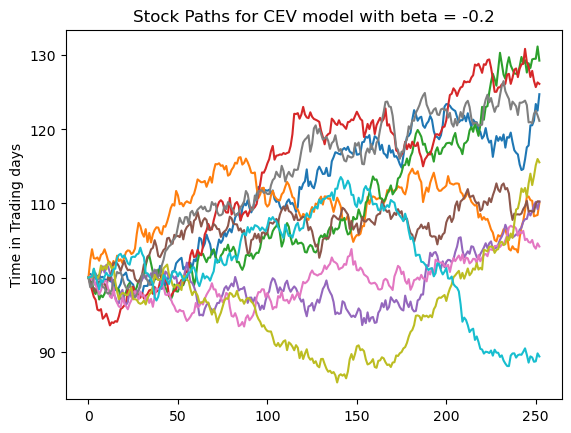

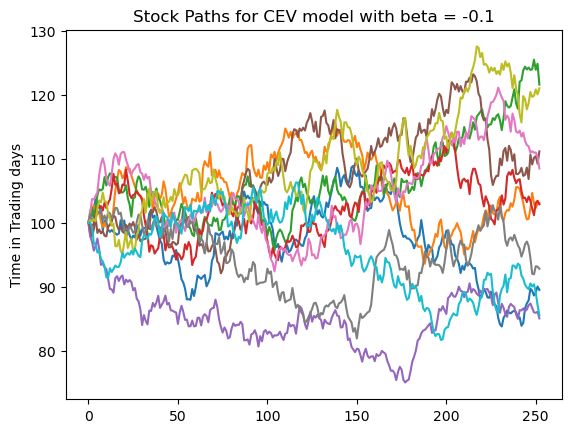

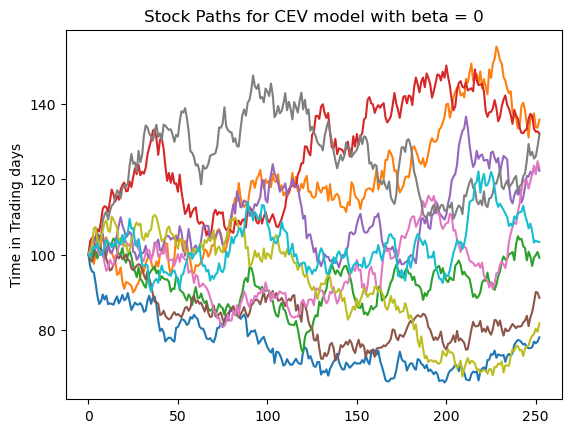

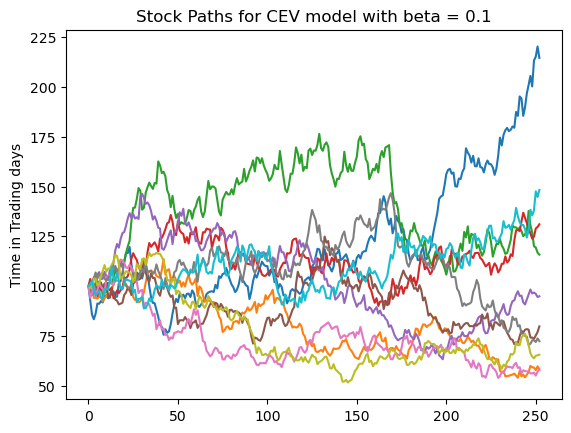

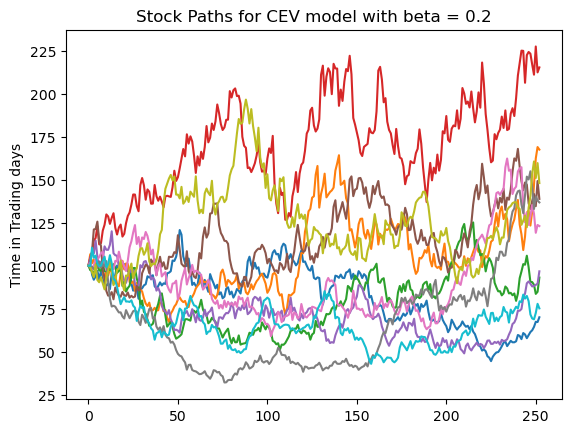

In [2]:
S0 = 100
T = 1
N = 252
sigma = 0.3
n_paths = 10
r = 0.10 
dt = T / N


def f(beta=0):
    ##Sample from a standard normal distribution 
    Z = np.random.randn(n_paths, N)
    paths = np.zeros((n_paths, N + 1))
    paths[:, 0] = S0

    for t in range(N):
        S_t = paths[:, t]

        #Next discrete step using our standard normal distribution and current stock price (Markov process)
        paths[:, t+1] = S_t + (r * S_t * dt + sigma * (S_t ** (beta+1)) * np.sqrt(dt) * Z[:, t])

        #We don't want stock value to go below 0
        paths[:, t+1] = np.maximum(paths[:, t+1], 0)
    return paths
#We shall generate stock paths corresponding to different values of the parameter \beta
betas = [-0.2,-0.1,0,0.1,0.2]
for b in betas:
    paths = f(b)
    plt.figure()
    for i in range(n_paths):
        plt.plot( paths[i])
    plt.title(f'Stock Paths for CEV model with beta = {b}')
    plt.ylabel('Time in Trading days')
    plt.show()
    




Note that for larger betas, the volatality increases drastically with stock price, and consequently the max values hit are much higher.